# A/B Testing Framework - Demonstration

This notebook demonstrates the capabilities of the A/B testing framework.
(本 Notebook 展示了 A/B 测试框架的核心功能。)

## Table of Contents (目录):
1. Library Imports - (导入必要的库和自定义模块)
2. Conversion Test - (转化率测试：适用于点击、注册等 0/1 类型的指标)
3. Continuous Metric Test - (连续指标测试：适用于收入、时长等数值类型的指标)
4. Sample Size Calculation - (样本量计算：实验前确定需要多少用户)
5. Test Power Analysis - (统计功效分析：评估实验结果的可靠性)

## 1. 库导入与环境设置 (Imports)

In [4]:
%load_ext autoreload
%autoreload 2
import sys
import warnings
warnings.filterwarnings('ignore')

# Import the core module
# Note: Ensure ab_testing.py is in the same directory
from test_ab_testing import ABTesting, TestType
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 8)

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Conversion Test (转化率测试)

Comparing conversion rates of two landing page versions:
本轮使用的是Z-Test

Data Generated Successfully:
• Total Sample Size: 7000
   user_id group  converted
0        0     A          0
1        1     A          1
2        2     A          0
3        3     A          0
4        4     A          0

Preliminary Statistics (初步统计数据):
       Total Users  Conversions  Conv. Rate %
group                                        
A             3500          337        0.0963
B             3500          429        0.1226

Relative Change (Lift): +27.31%

        ╔═══════════════════════════════════════════════════════════════╗
        ║                 A/B TEST REPORT (A/B 测试报告)                 ║
        ╠═══════════════════════════════════════════════════════════════╣
        ║ Test Type (测试类型): CONVERSION
        ║ Alpha (显著性水平): 0.05
        ║ Confidence Level (置信水平): 95.0%
        ╠═══════════════════════════════════════════════════════════════╣
        ║ SAMPLE SIZES (样本量):
        ║   • Group A (Control/对照组): 3,500
        ║   • Group B (Test/实验组):    3,500
      

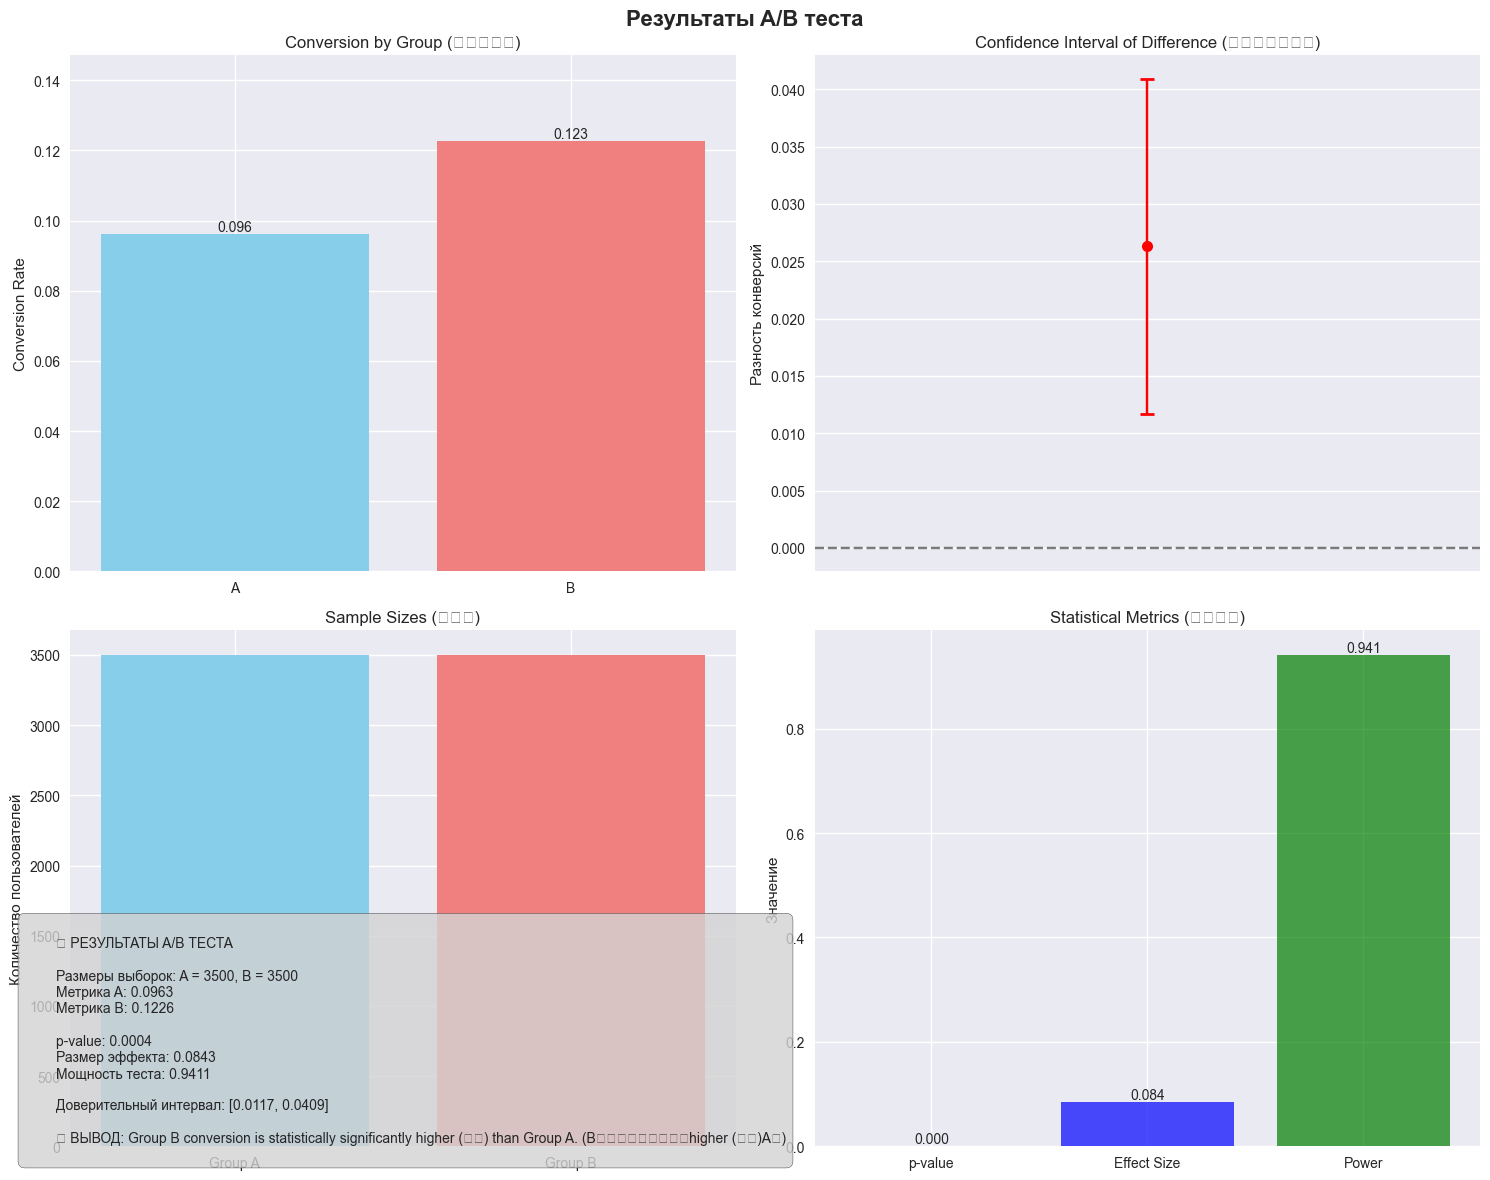

In [5]:
# 
# (比较两个版本着陆页的转化率)

# Initialize A/B test (Alpha = 0.05 是显著性水平，即报错概率控制在5%)
ab_test = ABTesting(alpha=0.05)

# Generate synthetic data for conversion test
# (生成模拟数据：n_control 对照组人数，n_treatment 实验组人数)
conversion_data = ab_test.generate_sample_data(
    n_control=3500,    # Control: Old version (旧版本)
    n_treatment=3500,  # Treatment: New version (新版本)
    test_type=TestType.CONVERSION,
    effect_size=0.025  # Expected lift: 2.5% (预期提升2.5%) --- This MDE is used to calculate the total sample size needed, but here we directly specify the MDE for data generation to simulate a realistic scenario.)
)

print(f"Data Generated Successfully:")
print(f"• Total Sample Size: {len(conversion_data)}")
print(conversion_data.head())

# Basic Data Analysis (基础数据统计)
summary = conversion_data.groupby('group')['converted'].agg(['count', 'sum', 'mean'])
summary.columns = ['Total Users', 'Conversions', 'Conv. Rate %']
summary['Conv. Rate %'] = summary['Conv. Rate %'].round(4)

print("\nPreliminary Statistics (初步统计数据):")
print(summary)

# Calculate Relative Change (计算相对提升)
conv_a = summary.loc['A', 'Conv. Rate %']
conv_b = summary.loc['B', 'Conv. Rate %']
relative_change = ((conv_b / conv_a - 1) * 100)

print(f"\nRelative Change (Lift): {relative_change:+.2f}%")

# Perform Statistical Test (执行统计检验 - 这里是 A/B 测试最核心的一步)
conversion_result = ab_test.conversion_test(conversion_data, 'converted')

# Output detailed report (输出详细报告)
print(ab_test.generate_report(conversion_result))

# Visualize results (结果可视化)
ab_test.plot_results(conversion_data, conversion_result)
plt.show()

## 3. 连续指标测试 (Continuous Metric Test)

This section analyzes metrics like Average Revenue Per User (ARPU) or session duration using a T-test.
(本节使用 T 检验分析如人均收入 ARPU 或页面停留时长等连续型指标。)

In [6]:
# Generate data for revenue test
# effect_size=0.12 means a 12% increase in revenue
revenue_data = ab_test.generate_sample_data(
    n_control=1000,
    n_treatment=1000,
    test_type=TestType.CONTINUOUS,
    effect_size=0.12  
)

print("Revenue Data Summary (营收数据摘要):")
revenue_summary = revenue_data.groupby('group')['revenue'].agg(['count', 'mean', 'std'])
# Column names in English and Chinese
revenue_summary.columns = ['Sample Size (样本量)', 'Mean Revenue (平均营收)', 'Std Dev (标准差)']
revenue_summary = revenue_summary.round(2)

print(revenue_summary)

# Calculate Relative Change (计算相对变化)
rev_change = ((revenue_summary.iloc[1, 1] / revenue_summary.iloc[0, 1] - 1) * 100)
print(f"\nRevenue Change (营收变化): {rev_change:+.2f}%")

Revenue Data Summary (营收数据摘要):
       Sample Size (样本量)  Mean Revenue (平均营收)  Std Dev (标准差)
group                                                       
A                   1000               100.48          24.48
B                   1000               102.97          24.94

Revenue Change (营收变化): +2.48%


In [7]:
# Perform T-test for continuous metrics (如营收、停留时长等)
# continuous_test will calculate p-value, confidence intervals, and effect size
revenue_result = ab_test.continuous_test(revenue_data, 'revenue')

print(ab_test.generate_report(revenue_result))


        ╔═══════════════════════════════════════════════════════════════╗
        ║                 A/B TEST REPORT (A/B 测试报告)                 ║
        ╠═══════════════════════════════════════════════════════════════╣
        ║ Test Type (测试类型): CONTINUOUS
        ║ Alpha (显著性水平): 0.05
        ║ Confidence Level (置信水平): 95.0%
        ╠═══════════════════════════════════════════════════════════════╣
        ║ SAMPLE SIZES (样本量):
        ║   • Group A (Control/对照组): 1,000
        ║   • Group B (Test/实验组):    1,000
        ║   • Total (总样本量):         2,000
        ╠═══════════════════════════════════════════════════════════════╣
        ║ KEY METRICS (核心指标):
        ║   • Group A Metric (A组指标): 100.4833
        ║   • Group B Metric (B组指标): 102.9709
        ║   • Absolute Difference (差值): 2.4876
        ║   • Relative Lift (相对提升): +2.48%
        ╠═══════════════════════════════════════════════════════════════╣
        ║ STATISTICAL RESULTS (统计结果):
        ║   • p-value (P值):           0.

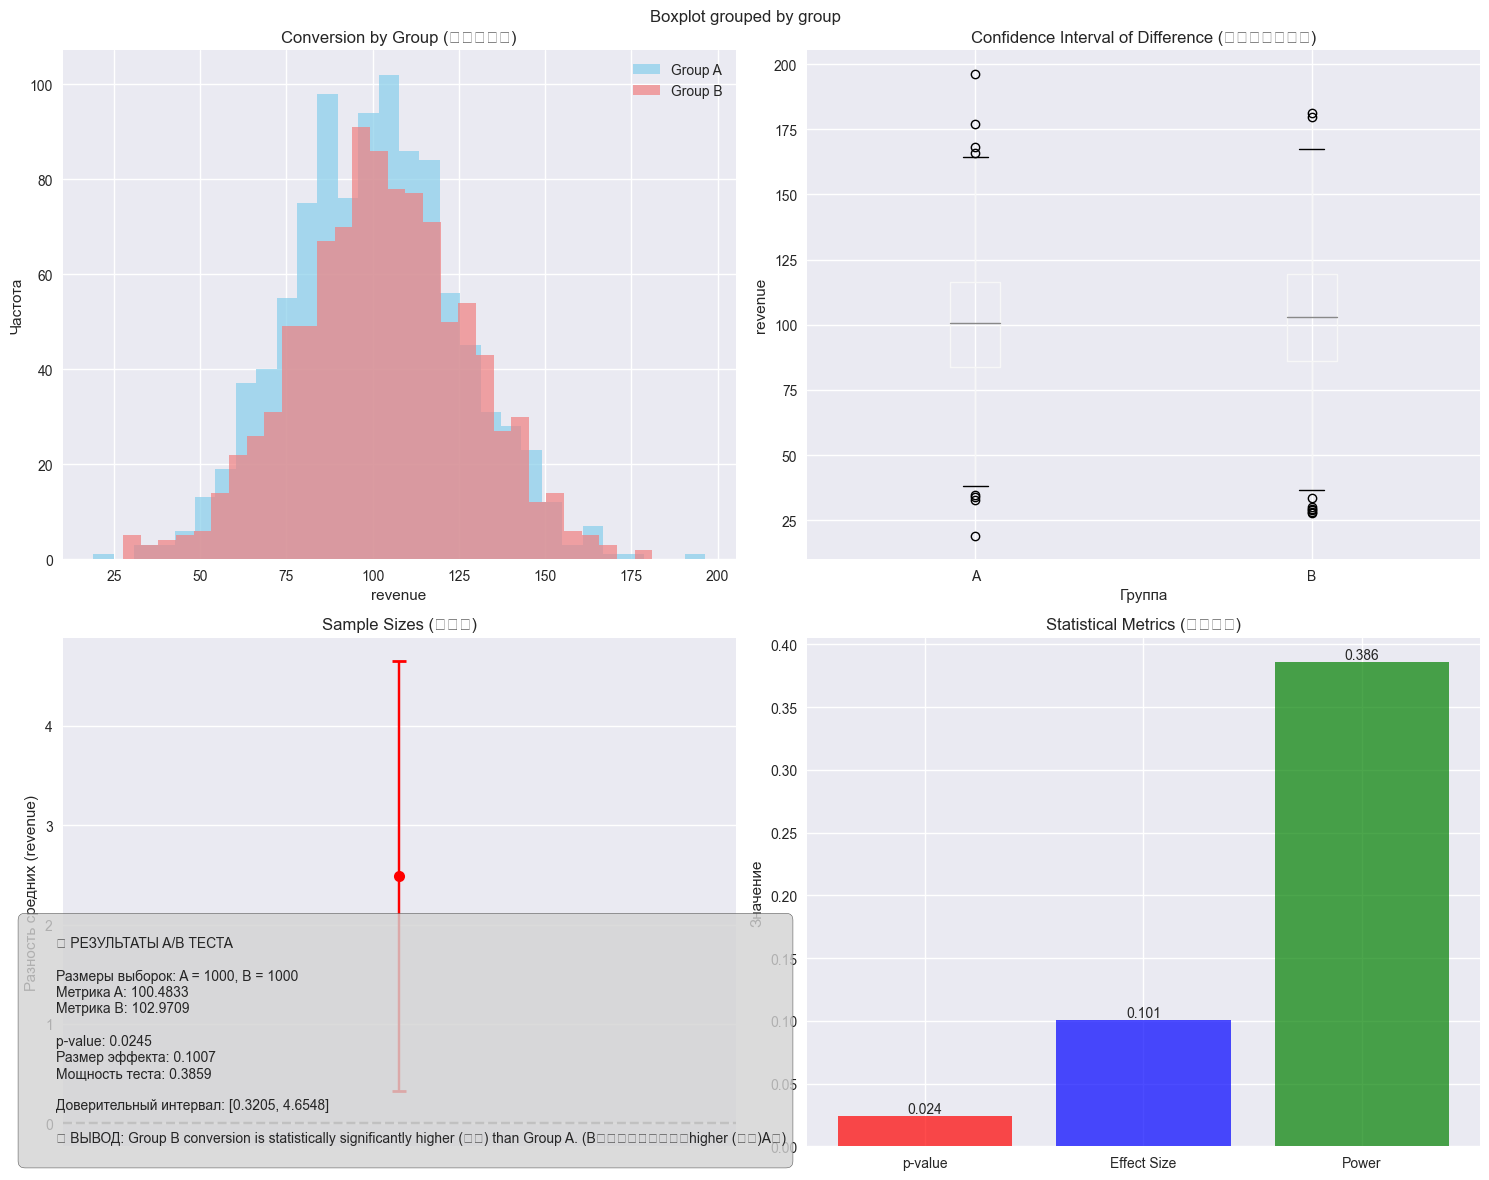

In [8]:
# Visualization of Results
ab_test.plot_results(revenue_data, revenue_result, metric_col='revenue')
plt.show()

## 4. 样本量计算 (Sample Size Calculation)

Before starting an experiment, we must determine how many users are needed to detect the expected effect.
(在开始实验前，我们必须确定需要多少用户才能检测到预期的业务提升。)

Baseline Rate (基准转化率): Current performance.

Expected Lift (预期提升)/MDE (Minumum Detactable Effect目标效应量): Minimum change we want to detect.

Power (统计功效): Probability of correctly rejecting the null hypothesis (usually 0.8).

In [9]:
# Different scenarios for experiment planning
# 不同的实验规划场景
scenarios = [
    {"name": "High Conv, Small Lift (高转化, 小提升)", "baseline": 0.15, "lift": 0.05},
    {"name": "Mid Conv, Mid Lift (中转化, 中提升)", "baseline": 0.08, "lift": 0.15},
    {"name": "Low Conv, Large Lift (低转化, 大提升)", "baseline": 0.02, "lift": 0.30},
]

print("📏 SAMPLE SIZE PLANNING (样本量规划)")
print("=" * 50)

sample_sizes = []

for scenario in scenarios:
    # 核心计算：基于基准率、预期提升、功效和显著性水平计算每组所需人数
    sample_size = ab_test.sample_size_calculator(
        baseline_rate=scenario["baseline"],
        expected_lift=scenario["lift"],
        power=0.8,
        alpha=0.05
    )
    
    sample_sizes.append({
        'Scenario (场景)': scenario['name'],
        'Baseline (基准转化率)': f"{scenario['baseline']:.1%}",
        'Exp. Lift (预期提升)': f"{scenario['lift']:.1%}",
        'Group Size (单组样本量)': f"{sample_size:,}",
        'Total Size (总样本量)': f"{sample_size * 2:,}"
    })

sample_df = pd.DataFrame(sample_sizes)
print(sample_df.to_string(index=False))

📏 SAMPLE SIZE PLANNING (样本量规划)
                   Scenario (场景) Baseline (基准转化率) Exp. Lift (预期提升) Group Size (单组样本量) Total Size (总样本量)
High Conv, Small Lift (高转化, 小提升)            15.0%             5.0%             36,311            72,622
   Mid Conv, Mid Lift (中转化, 中提升)             8.0%            15.0%              8,569            17,138
 Low Conv, Large Lift (低转化, 大提升)             2.0%            30.0%              9,799            19,598


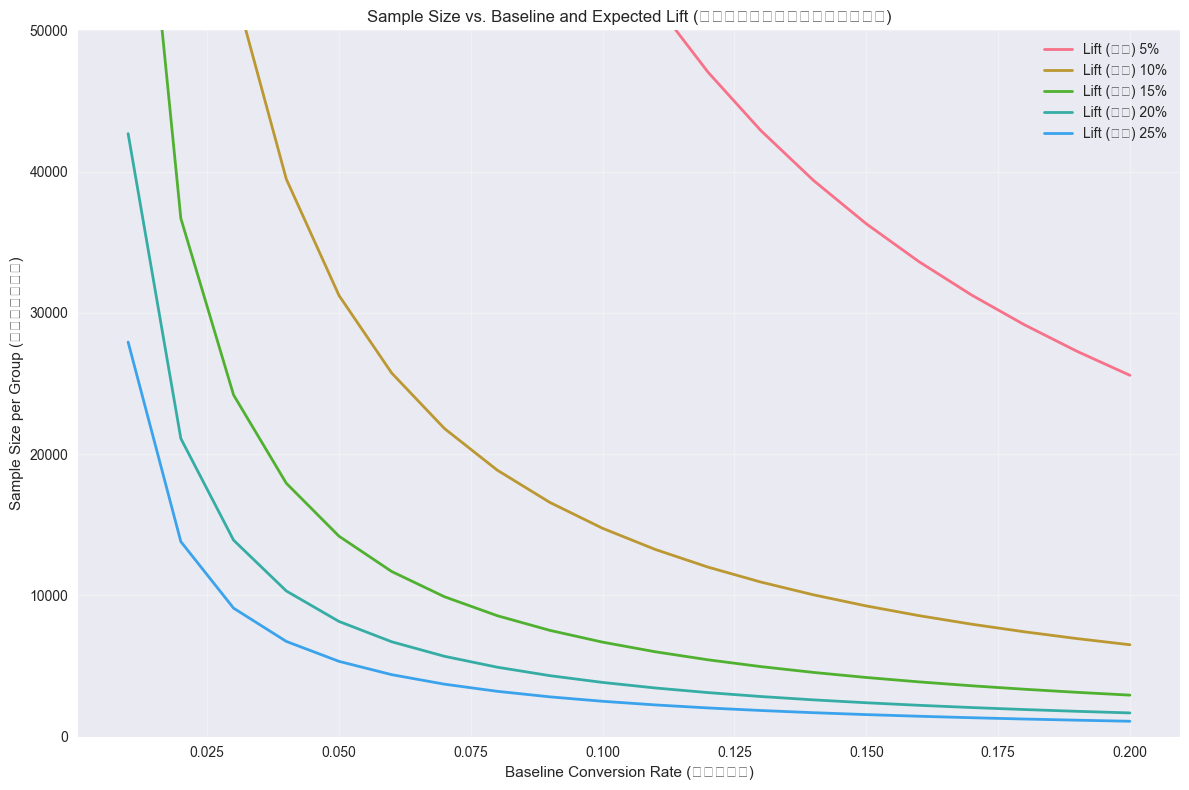

In [10]:
# --- English & Chinese Version ---
# Visualization: Sample Size vs. Parameters
# 可视化：样本量随参数变化的依赖关系

# Baselines from 1% to 20% (基准转化率从 1% 到 20%)
baselines = np.arange(0.01, 0.21, 0.01)
# Different target lifts (不同的预期提升幅度)
lifts = [0.05, 0.10, 0.15, 0.20, 0.25]

fig, ax = plt.subplots(figsize=(12, 8))

for lift in lifts:
    sizes = []
    for baseline in baselines:
        try:
            # Power fixed at 0.8 (功效固定为 0.8)
            size = ab_test.sample_size_calculator(baseline, lift, power=0.8)
            sizes.append(size)
        except:
            sizes.append(np.nan)
    
    # Label: "Lift X%" (标签：提升幅度 X%)
    ax.plot(baselines, sizes, label=f'Lift (提升) {lift:.0%}', linewidth=2)

ax.set_xlabel('Baseline Conversion Rate (基准转化率)')
ax.set_ylabel('Sample Size per Group (每组所需样本量)')
ax.set_title('Sample Size vs. Baseline and Expected Lift (样本量随基准率与预期提升的变化)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 50000) # Limit Y-axis for better visibility (限制Y轴以便观察)

plt.tight_layout()
plt.show()

## 5. Statistical Power Analysis {#power-analysis} 统计功效分析 

Goal: Investigate how sample size influences the sensitivity of the test to detect lift.
目标：研究样本量的大小如何影响测试检测指标提升的灵敏度。
其中，Power 为统计学中的(1 - β)指标

In [13]:
# --- Simulation of experiments with different sample sizes ---
# --- 不同样本量的实验模拟 ---
sample_sizes = [100, 300, 500, 1000, 2000, 3000]
effect_size = 0.03  # Fixed effect of 3% (固定预期提升为 3%)

results = []

for n in sample_sizes:
    # Generate data with fixed effect size
    # 生成具有固定效应量的模拟数据
    data = ab_test.generate_sample_data(
        n_control=n,
        n_treatment=n,
        test_type=TestType.CONVERSION,
        effect_size=effect_size
    )
    
    # Run the conversion test
    # 执行转化率检验
    result = ab_test.conversion_test(data)
    
    results.append({
        'Sample Size (n)': n,                  # 单组样本量
        'Total Size': n * 2,                   # 总样本量
        'p-value': result.p_value,             # P值
        'Power (功效)': result.power,           # 统计功效
        'Significant (显著)': result.is_significant, # 是否显著
        'Conv. A (转化率 A)': result.group_a_metric,  # A组转化率
        'Conv. B (转化率 B)': result.group_b_metric   # B组转化率
    })

# Convert to DataFrame for visualization
# 转换为 DataFrame 以便观察
power_df = pd.DataFrame(results)

print("POWER ANALYSIS FOR VARIOUS SAMPLE SIZES")
print("不同样本量的统计功效分析对比")
print("=" * 60)
print(power_df.round(4))

POWER ANALYSIS FOR VARIOUS SAMPLE SIZES
不同样本量的统计功效分析对比
   Sample Size (n)  Total Size  p-value  Power (功效)  Significant (显著)  \
0              100         200   0.0926      0.3898             False   
1              300         600   0.0359      0.5553              True   
2              500        1000   0.5535      0.0857             False   
3             1000        2000   0.0301      0.5828              True   
4             2000        4000   0.0078      0.7582              True   
5             3000        6000   0.0021      0.8672              True   

   Conv. A (转化率 A)  Conv. B (转化率 B)  
0           0.0900           0.1700  
1           0.0967           0.1533  
2           0.1100           0.1220  
3           0.1000           0.1310  
4           0.0985           0.1250  
5           0.0993           0.1243  


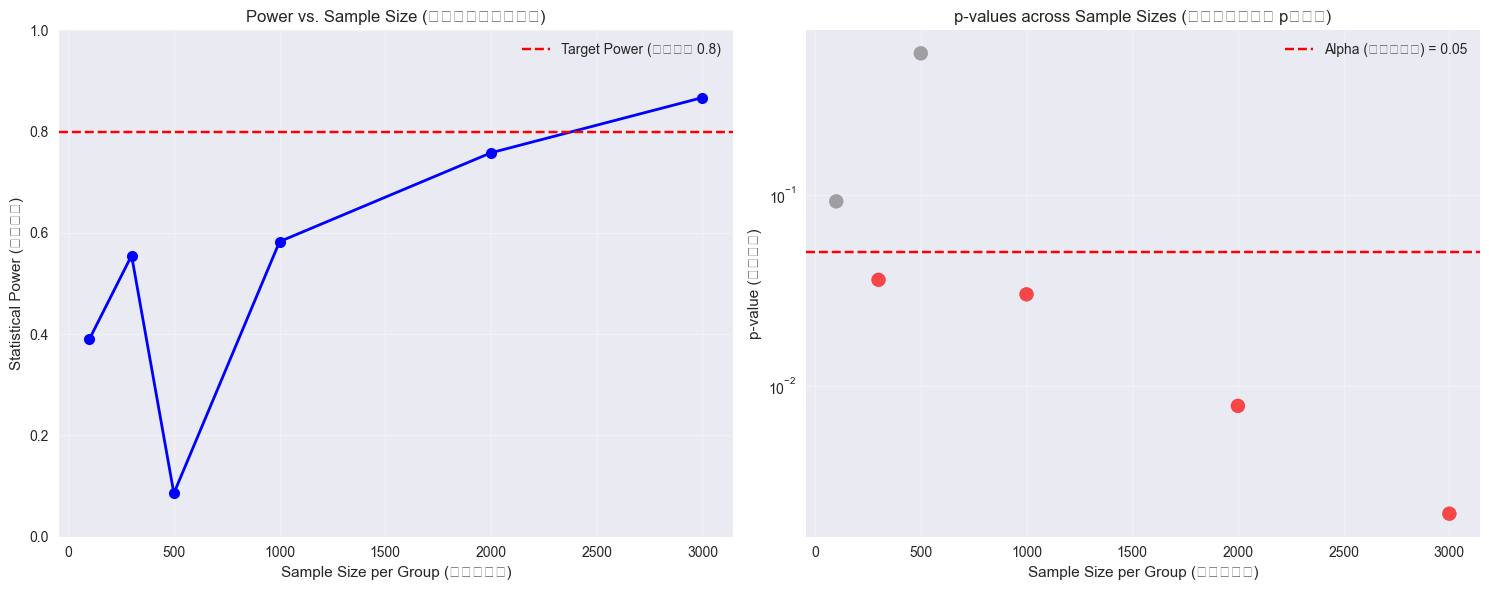

In [17]:
# --- Power Visualization (功效可视化) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Power Plot (功效曲线图)
# 展示随着样本量增加，我们检测出真实差异的能力如何提升
ax1.plot(power_df['Sample Size (n)'], power_df['Power (功效)'], 'bo-', linewidth=2, markersize=8)
ax1.axhline(y=0.8, color='red', linestyle='--', label='Target Power (目标功效 0.8)')
ax1.set_xlabel('Sample Size per Group (单组样本量)')
ax1.set_ylabel('Statistical Power (统计功效)')
ax1.set_title('Power vs. Sample Size (功效随样本量的变化)')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim(0, 1)

# 2. p-values Plot (p值散点图)
# 展示样本量如何降低“随机噪音”的影响，使结果趋于显著
# Significant points are red, non-significant are gray (显著点为红色，不显著为灰色)
colors = ['red' if p < 0.05 else 'gray' for p in power_df['p-value']]
ax2.scatter(power_df['Sample Size (n)'], power_df['p-value'], c=colors, s=100, alpha=0.7)
ax2.axhline(y=0.05, color='red', linestyle='--', label='Alpha (显著性水平) = 0.05')
ax2.set_xlabel('Sample Size per Group (单组样本量)')
ax2.set_ylabel('p-value (对数刻度)')
ax2.set_title('p-values across Sample Sizes (不同样本量下的 p值分布)')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_yscale('log') # 使用对数刻度更清楚地观察小数值的变化

plt.tight_layout()
plt.show()

## Conclusion (总结)
In this notebook, we demonstrated (在本 Notebook 中，我们演示了):

Conversion Tests (转化率检验) - For binomial metrics like CR and CTR. (适用于二项分布指标，如转化率、点击率。)

Continuous Metric Tests (连续指标检验) - For average values like Revenue and Time on Site. (适用于数值均值，如营收、页面停留时长。)

Experiment Planning (实验规划) - Calculating the required sample size. (计算所需的最小样本量。)

Power Analysis (统计功效分析) - Understanding the probability of detecting real effects. (理解检测出真实业务提升的概率。)

Recommendations (建议):
Plan Sample Size in Advance (提前规划样本量): Always calculate based on the MDE (Minimum Detectable Effect) before starting. (在开始前，始终根据最小可检测效应计算样本量。)

Target Power 0.8+ (追求 0.8 以上的功效): To ensure reliable detection of real improvements. (确保能可靠地捕捉到真实的业务改进。)

Use Confidence Intervals (使用置信区间): To evaluate the practical range of the impact. (用于评估改动影响的实际波动范围。)

Segment Analysis (维度分析): Dive deeper into sub-groups for better insights. (对细分群体进行深入分析，获取更多洞察。)